In [30]:
#import packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import xgboost as xgb
from ML_Modelevaluation import SoilModel

In [31]:
######################## Define the text size of each plot globally ###########
SMALL_SIZE = 10
MEDIUM_SIZE = 10
BIGGER_SIZE = 10

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=SMALL_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=SMALL_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
plt.rcParams["font.family"] = "Arial"
######################## Define the text size of each plot globally ###########

In [32]:
# =============================================================================
# Benchmark Comparison
# =============================================================================
file_names = []

example = r'102_SyntheticExample_Final' ## needs user interaction
path_user = r'C:\Users\haris\Documents\GitHub\MLpFEM\data\\'
path = path_user + example + "\\03_TargetValues\\"

file = r"Triaxial test_q_eps1.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
eps_y_opt = df_data_triax.iloc[0,:]  
q_opt = df_data_triax.iloc[1,:] 

file = r"Triaxial test_epsvol.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
eps_y_opt = df_data_triax.iloc[0,:] 
eps_vol_opt  = df_data_triax.iloc[1,:] 

file = r"Triaxial test_path.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
p_opt_path = df_data_triax.iloc[0,:] 
q_opt_path  = df_data_triax.iloc[1,:] 

file = r"Oedometer.txt"
file_names.append(file)
df_data_triax = pd.read_csv(path+file, sep = "\t", header=None)
df_data_triax = df_data_triax.transpose()
eps_y_oed_opt = df_data_triax.iloc[0,:]  
sig_1_opt  = df_data_triax.iloc[1,:] 


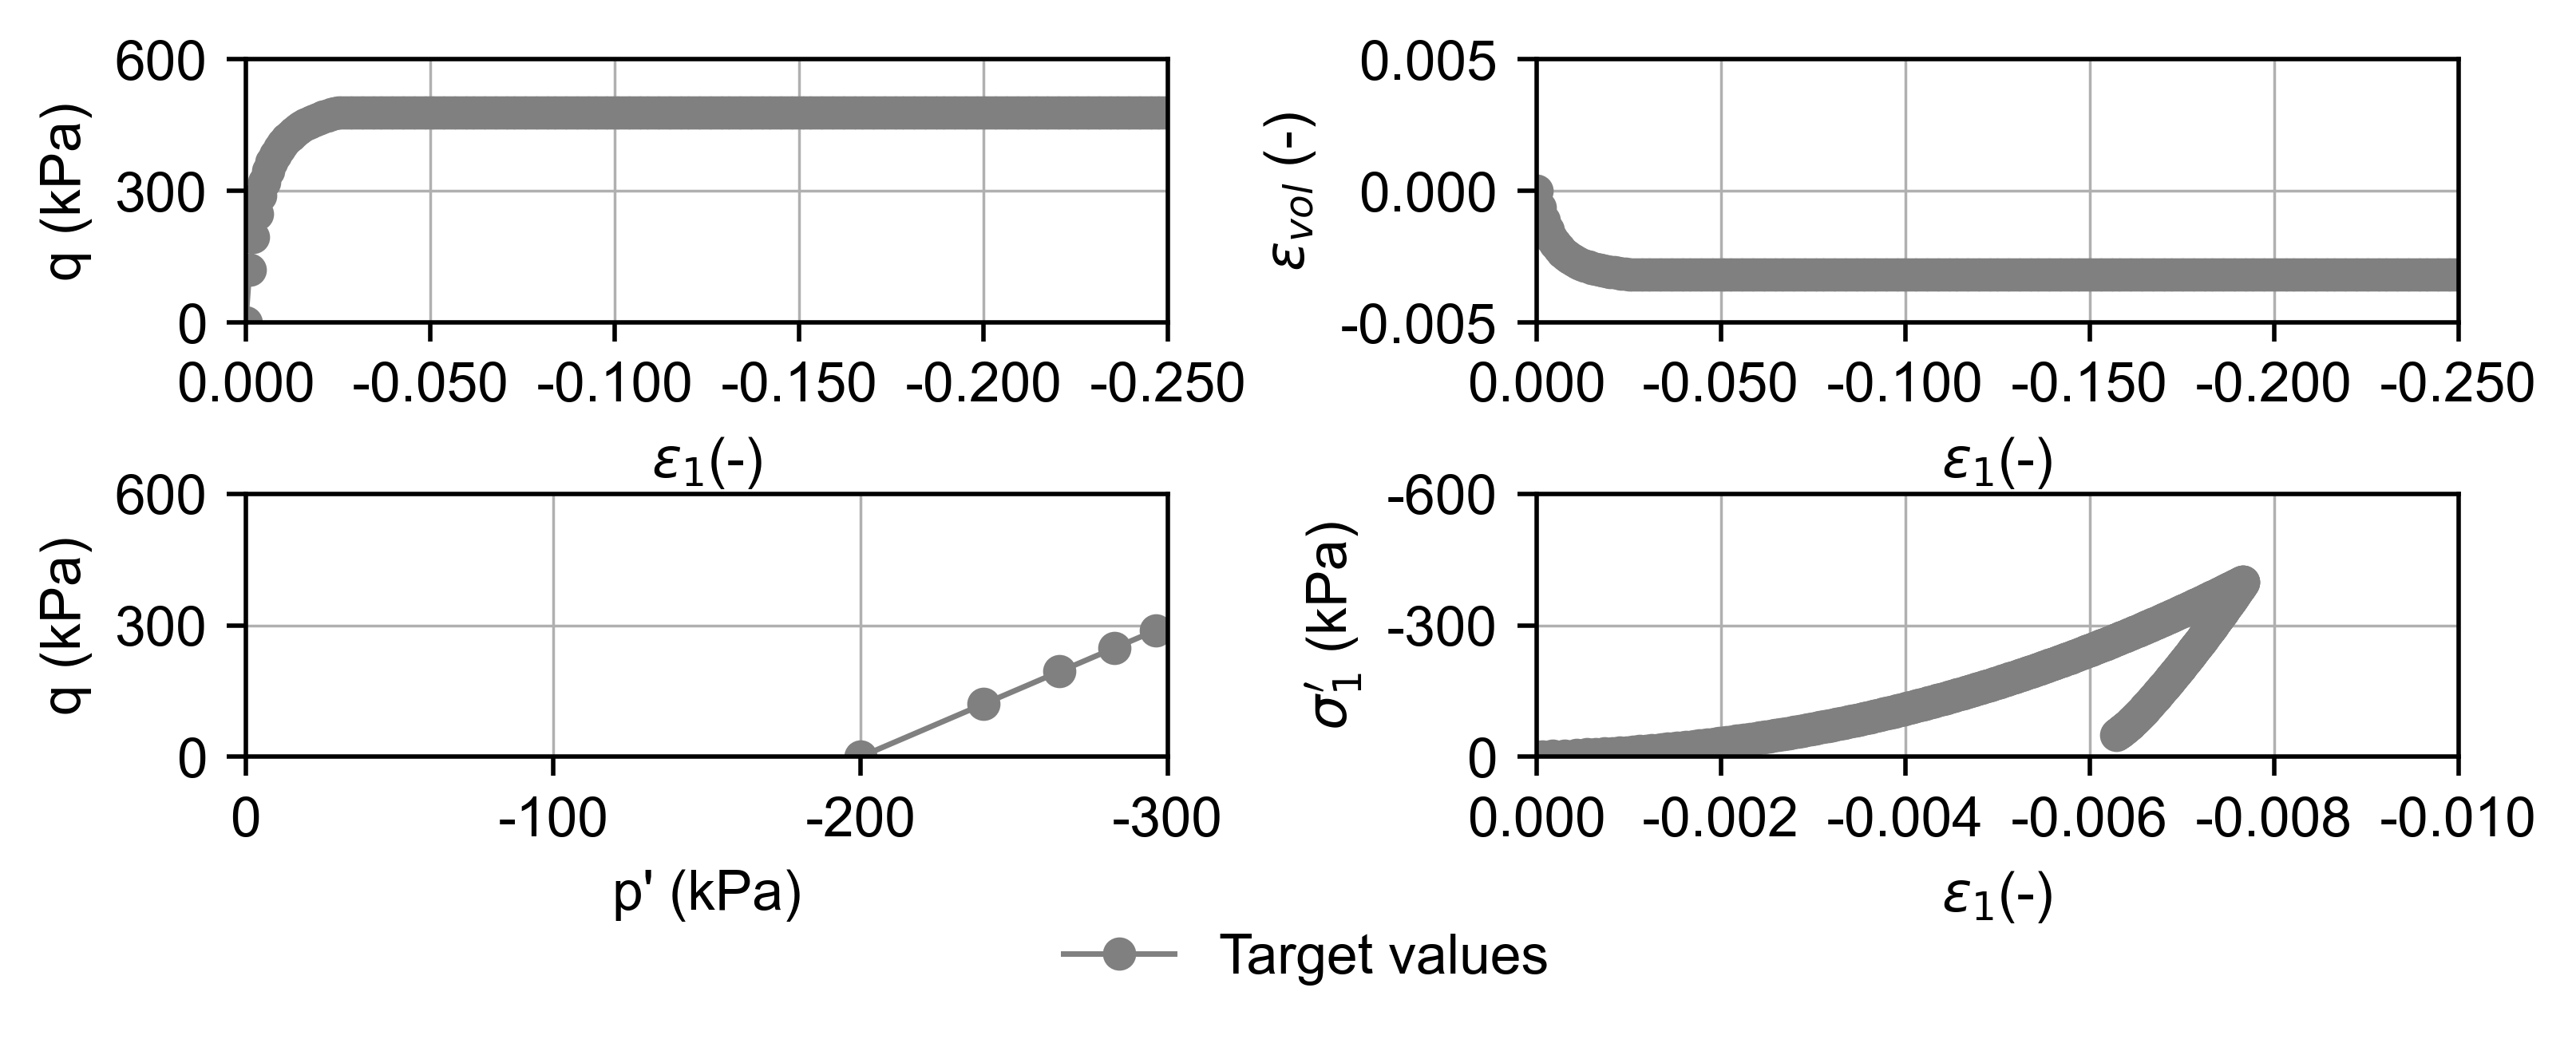

In [33]:
examples = [example]
folders = ['03_TargetValues\\']
labels = ['Target values']

colors = ['gray', 'k','g', 'b','r','g']
markers = ['o', 's', 'd', 's', '+']

markersizes = [5, 2, 2, 2, 0]
markeverys= [1,5,8,10,12]

cm = 1/2.54  # centimeters in inches

for k, example in enumerate(examples):
    fig, axs = plt.subplots(2, 2, figsize=(16*cm, 6*cm), dpi=500)

    for i, folder in enumerate(folders):
        for j, file_name in enumerate(file_names):
            df_data_syn = pd.read_csv(path_user + example + "\\" + folder + file_name, sep="\t", header=None)
            x = df_data_syn.iloc[:, 0]
            y = df_data_syn.iloc[:, 1]
    
            x = np.array(x)
            y = np.array(y)
    
            axs[j//2, j%2].plot(x, y, marker = markers[i], color=colors[i], label=labels[i], linewidth=1, markersize=markersizes[i], markevery=markeverys[i])
            axs[j//2, j%2].grid(True, linewidth=0.5)
            axs[j//2, j%2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            axs[j//2, j%2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            
            axs[1, 0].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[1, 0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[0, 0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[1, 1].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
    
            # Invert x-axis for all plots
            axs[j//2, j%2].invert_xaxis()

            # Invert y-axis for the last plot
            if j == len(file_names) - 1:
                axs[j//2, j%2].invert_yaxis()
    
            axs[j//2, j%2].set_xlabel('$\epsilon_{1}$(-)')
            axs[1, 0].set_xlabel("p' (kPa)")
            axs[0, 0].set_ylabel('q (kPa)')
            axs[1, 0].set_ylabel('q (kPa)')
            axs[0, 1].set_ylabel('$\epsilon_{vol}$ (-)')
            axs[1, 1].set_ylabel("$\sigma_{1}'$ (kPa)")

            if j == 3:
                default_ticks = axs[1, 0].get_xticks()
                axs[1, 0].set_yticks([0,300,600])
                axs[1, 0].set_ylim(0)
                axs[1, 0].set_xlim(xmin = 0, xmax = -300)
            if j == 0:
                axs[0, 0].set_xlim(0, -0.25)
                axs[0, 0].set_yticks([0,300,600])
                axs[0, 0].set_ylim(0)
            if j == 1:
                axs[0, 1].set_yticks([-0.005, 0,0.005])
                axs[0, 1].set_xlim(0,-0.25)

            if j == 2:
                axs[1, 1].set_ylim(-600,0)
                axs[1, 1].set_yticks([0,-300,-600])
                axs[1, 1].set_xlim(-0.010,0)
                
    # Create legend outside the loop
    plt.legend(loc='upper center', bbox_to_anchor=(-.25, -.48), frameon=False, ncol=4)
    plt.subplots_adjust(left=0.08, right=0.96, bottom=0.24, top=0.98, wspace=0.40, hspace=0.65)

    plt.savefig(r"../graphics/"+"SyntheticData_"+f"{example}"+".png", dpi=1000)


In [34]:
soil_model = SoilModel()

df_sig = pd.DataFrame()
df_eps = pd.DataFrame()

# Convert to numpy arrays if they are pandas Series
if isinstance(sig_1_opt, pd.Series):
    sig_1_opt = sig_1_opt.to_numpy()
if isinstance(eps_y_oed_opt, pd.Series):
    eps_y_oed_opt = eps_y_oed_opt.to_numpy()

# Check if sig_1_opt and eps_y_oed_opt have only one column
if len(sig_1_opt.shape) == 1:
    sig_1_opt = sig_1_opt.reshape(1, -1)
if len(eps_y_oed_opt.shape) == 1:
    eps_y_oed_opt = eps_y_oed_opt.reshape(1, -1)

    

for sig, eps in zip(sig_1_opt, eps_y_oed_opt):
    min_index = np.argmin(sig)
    degree = 15

    # Loading
    eps1_section_1 = eps[:min_index + 1]
    sig1_section_1 = sig[:min_index + 1]

    # Unloading
    eps1_section_2 = eps[min_index:]
    sig1_section_2 = sig[min_index:]

    # Filter for sigma not less than -50
    mask = sig1_section_2 <= -50
    cutoff_indices = np.where(~mask)[0]  # Indices that do not meet the condition
    
    if len(cutoff_indices) > 0:
        #print("Indices being cut off for sig1_section_2:", cutoff_indices)
        eps1_section_2 = eps1_section_2[:cutoff_indices[0]]
        sig1_section_2 = sig1_section_2[:cutoff_indices[0]]
    
    eps1_section_1_syn = np.linspace(0, min(eps1_section_1), num=375)
    eps1_section_2_syn = np.linspace(min(eps1_section_1), max(eps1_section_2), num=375)

    sig1_pred_section_1 = soil_model.interpolation_scikit(x_true=eps1_section_1, y_true=sig1_section_1, x_check=eps1_section_1_syn, degree=degree)
    sig1_pred_section_2 = soil_model.interpolation_scikit(x_true=eps1_section_2, y_true=sig1_section_2, x_check=eps1_section_2_syn, degree=degree)
    #print(max(sig1_pred_section_2))

    # Convert to DataFrame and transpose
    sig1_pred_section_1_df = pd.DataFrame(sig1_pred_section_1).T
    sig1_pred_section_2_df = pd.DataFrame(sig1_pred_section_2).T
    eps1_section_1_syn_df = pd.DataFrame(eps1_section_1_syn).T
    eps1_section_2_syn_df = pd.DataFrame(eps1_section_2_syn).T

    # Concatenate horizontally
    sig_combined_df = pd.concat([sig1_pred_section_1_df, sig1_pred_section_2_df], axis=1)
    eps_combined_df = pd.concat([eps1_section_1_syn_df, eps1_section_2_syn_df], axis=1)

    df_sig = pd.concat([df_sig, sig_combined_df], ignore_index=True)
    df_eps = pd.concat([df_eps, eps_combined_df], ignore_index=True)

In [35]:
df_q = pd.DataFrame()
df_p = pd.DataFrame()


# Convert to numpy arrays if they are pandas Series
if isinstance(q_opt_path, pd.Series):
    q_opt_path = q_opt_path.to_numpy()
if isinstance(p_opt_path, pd.Series):
    p_opt_path = p_opt_path.to_numpy()

# Check if sig_1_opt and eps_y_oed_opt have only one column
if len(q_opt_path.shape) == 1:
    q_opt_path = q_opt_path.reshape(1, -1)
if len(p_opt_path.shape) == 1:
    p_opt_path = p_opt_path.reshape(1, -1)


for q_a, p_a in zip(q_opt_path, p_opt_path):
    max_q, min_q = max(q_a), min(q_a)
    max_p, min_p = max(p_a), min(p_a)
    
    q_export = np.linspace(min_q, max_q, num=250)
    p_export = np.linspace(max_p, min_p, num=250)

    # Convert to DataFrame and transpose
    q_export = pd.DataFrame(q_export).T
    p_export = pd.DataFrame(p_export).T

    # Concatenate horizontally
    df_q = pd.concat([df_q, q_export], axis=0)
    df_p = pd.concat([df_p, p_export], axis=0)

In [36]:
X_triax = np.hstack((q_opt, eps_y_opt, eps_vol_opt, eps_y_opt))
X_triax = np.reshape(X_triax, (1, -1))
X_triax = pd.DataFrame(X_triax)

# Ensure that all DataFrames have unique indices
df_q = df_q.reset_index(drop=True)
df_p = df_p.reset_index(drop=True)
X_triax = X_triax.reset_index(drop=True)

# Concatenate DataFrames
X_triax = pd.concat([X_triax, df_q, df_p], ignore_index=False, sort=False, axis=1)
X_oedo = pd.concat([df_sig, df_eps], ignore_index = True, sort = False, axis = 1)

In [37]:
print("Triaxial test:", len(X_triax.columns))
print("Oedometer test:", len(X_oedo.columns))

Triaxial test: 1500
Oedometer test: 1500


In [38]:
X = pd.concat([X_triax, X_oedo], ignore_index = True, sort = False, axis = 1)

In [39]:
X

,0,1,2,3,4,5,6,7,8,9,...,2990,2991,2992,2993,2994,2995,2996,2997,2998,2999
0,0.0,120.07624,194.530421,248.19815,288.854793,320.505572,345.656851,365.94478,382.57653,396.39542,...,-0.006323,-0.006319,-0.006315,-0.006312,-0.006308,-0.006304,-0.006301,-0.006297,-0.006293,-0.00629


In [40]:
# =============================================================================
# Benchmark Comparison
# =============================================================================
input_column = ['E50ref', 'Eoedref', 'Eurref', 
                'phi','cref', 'psi', 
                'm', 'nu', 
                'Rf', 'K0NC', 'CellPressure']

loaded_model = xgb.Booster()
loaded_model.load_model(f"A_HS_model_[200].bin")


d_eval_1 = xgb.DMatrix(X,)
predictions = loaded_model.predict(d_eval_1)

In [41]:
#model prediction
for i in range(len(input_column)):
    print(f"{input_column[i]}: {predictions[0,i]:.3f}")

E50ref: 60677.844
Eoedref: 50205.535
Eurref: 210677.375
phi: 32.989
cref: 0.000
psi: -0.000
m: 0.549
nu: 0.198
Rf: 0.905
K0NC: 0.456
CellPressure: 200.000


In [42]:
with open(f'..\\data\pred_analysis_synthetictest_{example}.txt', 'w', encoding='utf-8') as file:
    for i in range(len(input_column)):
        file.write(f"{input_column[i]}: \t {predictions[0,i]:.3f}\n")

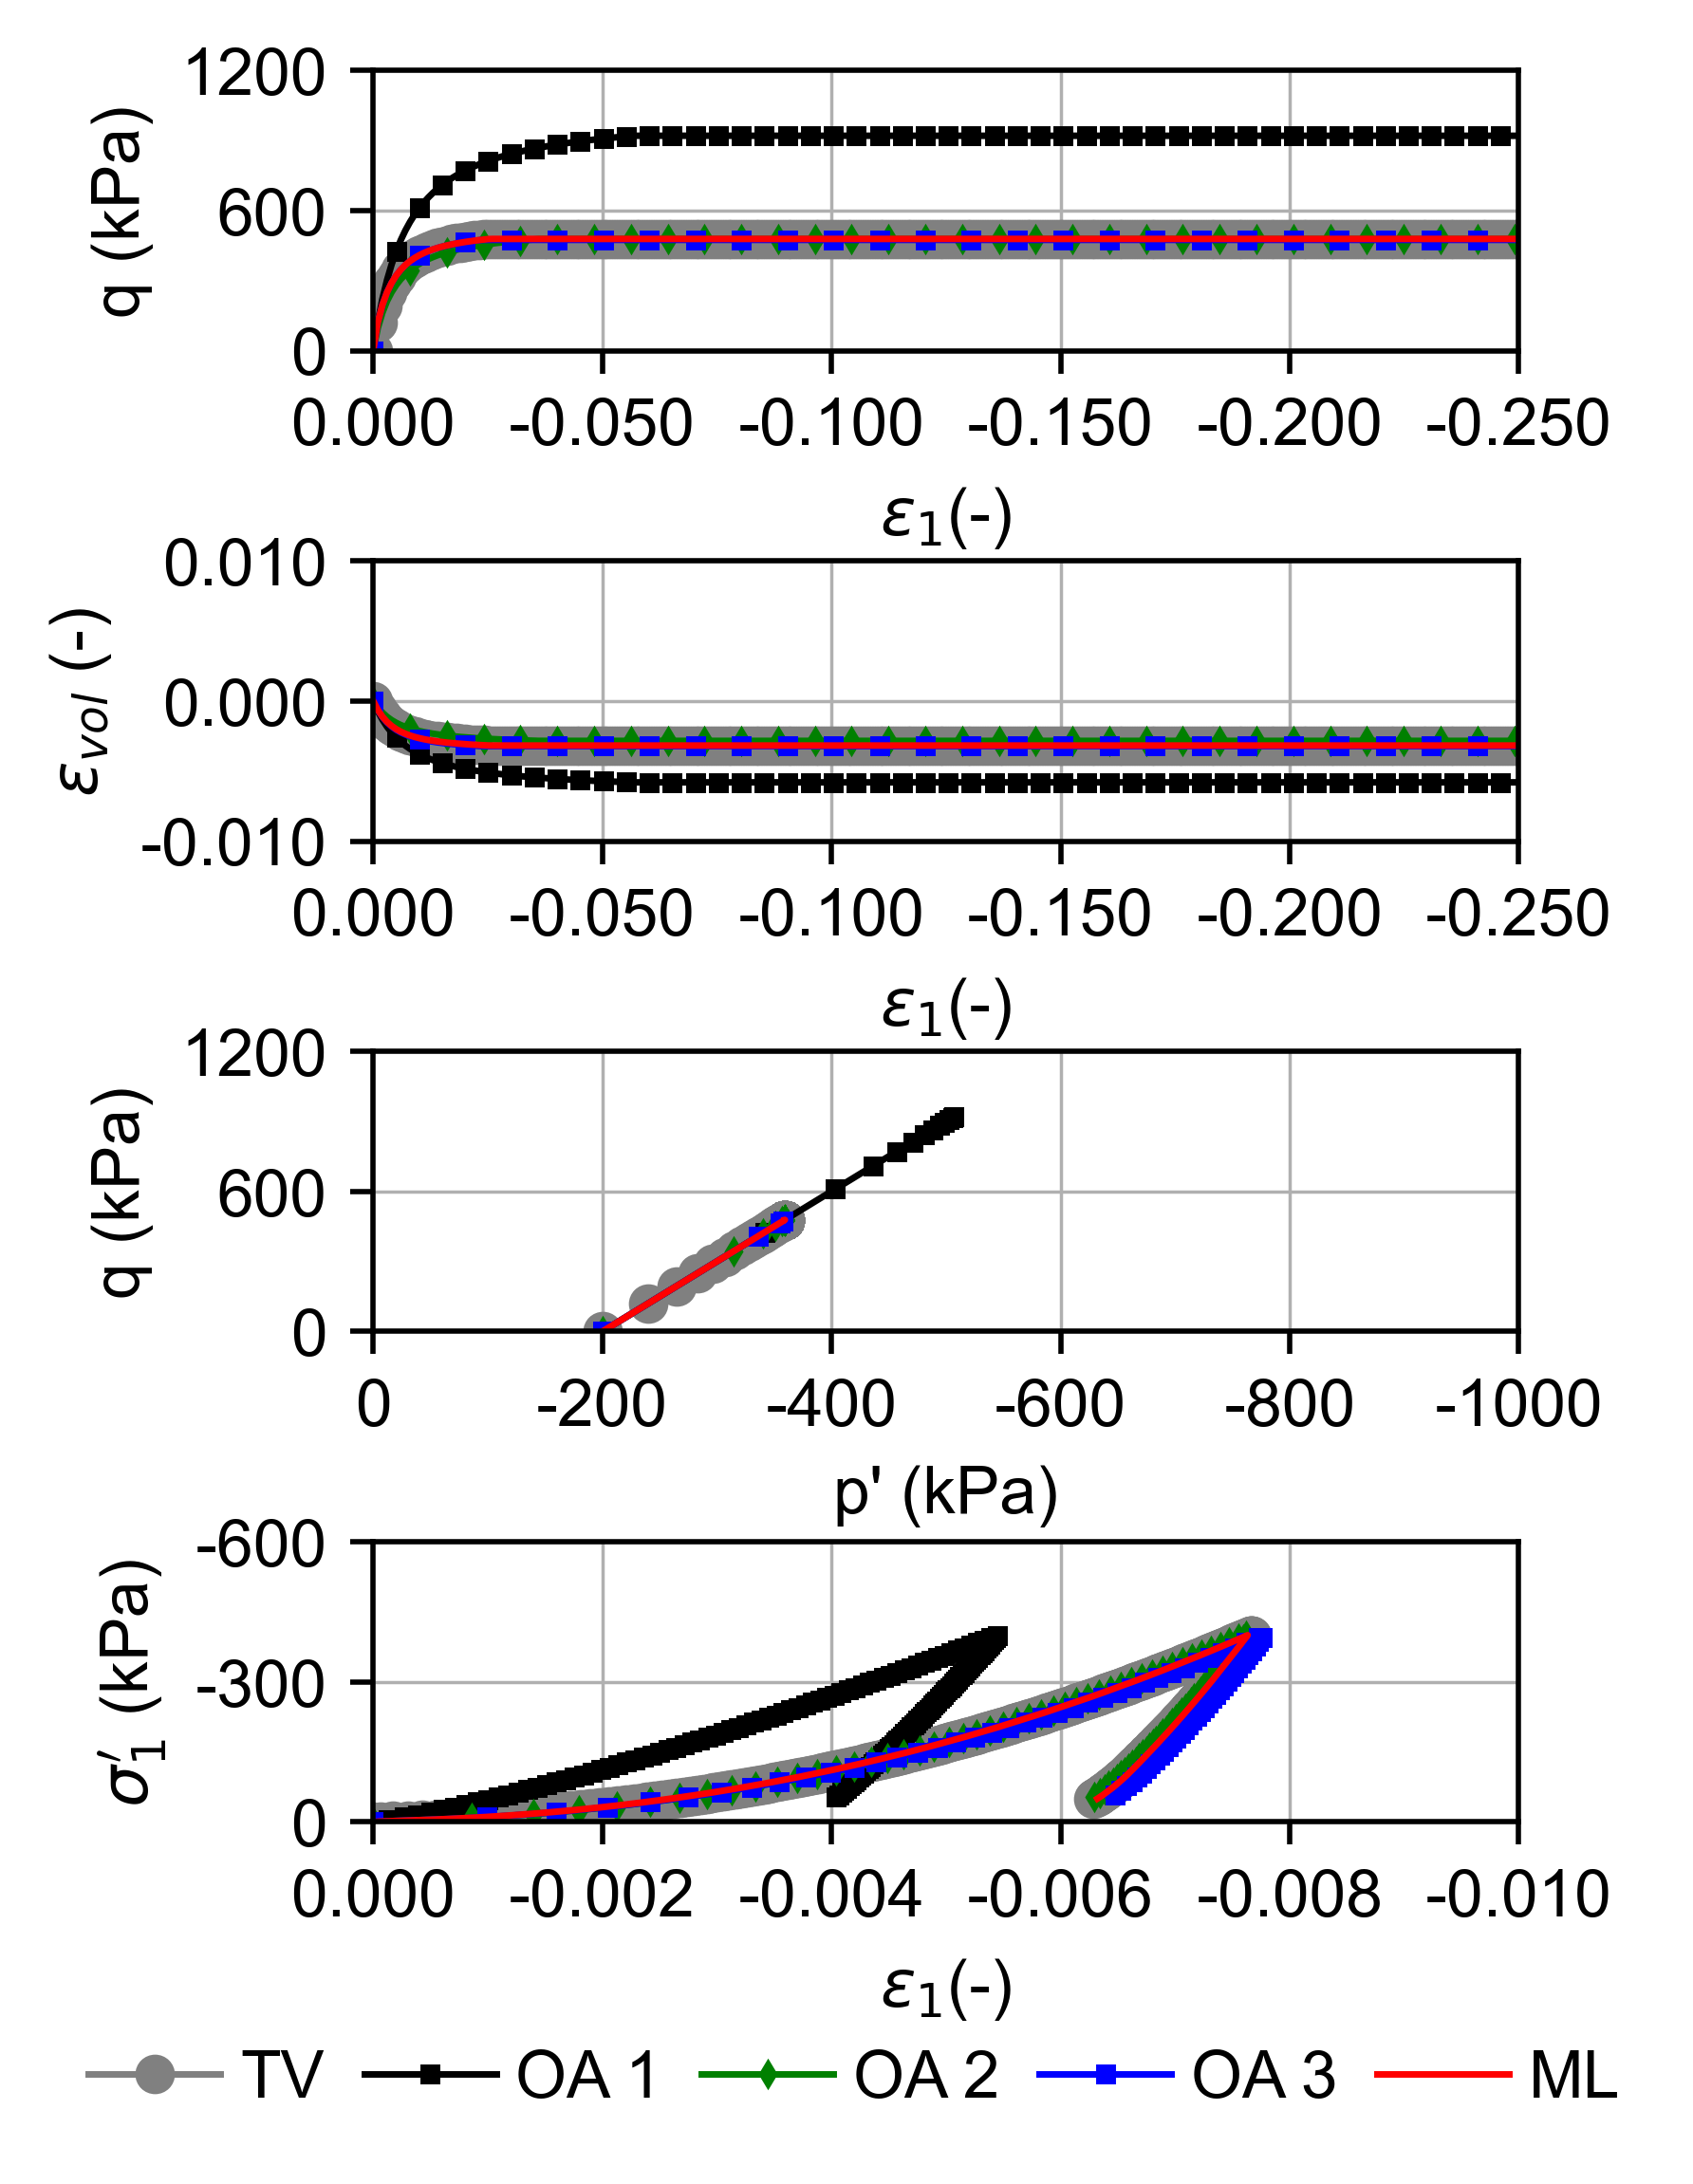

In [45]:
folders = ['03_TargetValues\\', '01_ParameterOptimization_OA1\\', '02_ParameterOptimization_OA2\\','03_ParameterOptimization_OA3\\','10_MachineLearning\\']
labels = ['TV','OA 1','OA 2','OA 3','ML']

for k, example in enumerate(examples):
    fig, axs = plt.subplots(4, 1, figsize=(8.4 * cm, 11.1 * cm), dpi=500)  # Changed to 4 rows, 1 column

    for i, folder in enumerate(folders):
        for j, file_name in enumerate(file_names):
            df_data_syn = pd.read_csv(path_user + example + "\\" + folder + file_name, sep="\t", header=None)
            x = df_data_syn.iloc[:, 0]
            y = df_data_syn.iloc[:, 1]

            x = np.array(x)
            y = np.array(y)

            axs[j].plot(x, y, marker=markers[i], color=colors[i], label=labels[i], linewidth=1, markersize=markersizes[i], markevery=markeverys[i])
            axs[j].grid(True, linewidth=0.5)
            axs[j].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))
            axs[j].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.3f'))

            axs[2].xaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[2].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[0].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))
            axs[3].yaxis.set_major_formatter(ticker.FormatStrFormatter('%.0f'))

            # Invert x-axis for all plots
            axs[j].invert_xaxis()
            axs[j].set_xlabel('$\epsilon_{1}$(-)')
            
            axs[2].set_xlabel("p' (kPa)")
            axs[0].set_ylabel('q (kPa)')
            axs[2].set_ylabel('q (kPa)')

            axs[1].set_ylabel('$\epsilon_{vol}$ (-)')
            axs[3].set_ylabel("$\sigma_{1}'$ (kPa)")

            if j == 2:  # stress path
                default_ticks = axs[1].get_xticks()
                axs[2].set_yticks([0, 600, 1200])
                axs[2].set_ylim(0)
                axs[2].set_xlim(xmin=0, xmax=-1000)
            if j == 0:  # stress strain
                axs[0].set_xlim(0, -0.25)
                axs[0].set_yticks([0, 600, 1200])
                axs[0].set_ylim(0)
            if j == 1:  # volumetric behaviour
                axs[1].set_yticks([-0.01, 0, 0.01])
                axs[1].set_xlim(0, -0.25)
            if j == 3:  # oedoemeter
                axs[3].set_ylim(-600, 0)
                axs[3].set_yticks([0, -300, -600])
                axs[3].set_xlim(-0.010, 0)
                axs[3].invert_yaxis()
                axs[3].invert_xaxis()

    # Create legend outside the loop
    plt.legend(loc='upper center', bbox_to_anchor=(0.42, -.60), frameon=False, ncol=5, handletextpad=0.3, columnspacing=0.6)
    plt.subplots_adjust(left=0.20, right=0.93, bottom=0.14, top=0.985, wspace=0.40, hspace=0.75)
    plt.savefig(r"../graphics/" + "Synthetic_" + f"{example}" + ".png", dpi=1000)